# torch


uv pip install torchvision==0.24.1 torchviz


### c'est quasi comme numpy

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [17]:
a = np.ones((5,10))
a

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [18]:
a = torch.ones((5,10))
a

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [19]:
b = torch.rand((10, 3))
b

tensor([[0.7417, 0.8734, 0.0959],
        [0.9018, 0.0771, 0.9914],
        [0.4457, 0.6734, 0.5321],
        [0.9642, 0.9350, 0.3735],
        [0.9628, 0.7190, 0.3105],
        [0.5835, 0.0728, 0.5101],
        [0.1230, 0.3619, 0.6945],
        [0.9466, 0.1942, 0.1757],
        [0.9080, 0.5558, 0.0468],
        [0.3000, 0.0735, 0.8850]])

In [20]:
a @ b

tensor([[6.8772, 4.5362, 4.6155],
        [6.8772, 4.5362, 4.6155],
        [6.8772, 4.5362, 4.6155],
        [6.8772, 4.5362, 4.6155],
        [6.8772, 4.5362, 4.6155]])

In [21]:
a + 1

tensor([[2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.]])

In [22]:
a.shape

torch.Size([5, 10])

In [23]:
a.dtype

torch.float32

### mais ça marche sur GPU (quand on est riche)

In [24]:
a.device

device(type='cpu')

In [10]:
a2 = a.to('cuda')


/home/samuel/.virtualenvs/env_formation/lib/python3.13/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Quadro P2000 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/samuel/.virtualenvs/env_formation/lib/python3.13/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/samuel/.virtualenvs/env_formation/lib/python3.13/site-packages/torch/cuda/__init__.py:435: UserWarning: 
Quadro P2000 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Quadro P2000 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/loc

In [11]:
a2 + 2

AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
n = 1000
a = torch.rand((n, n))
b = torch.rand((n, n))
a2 = a.to('cuda')
b2 = b.to('cuda')


In [ ]:
%timeit a @ b
%timeit a2 @ b2


3.41 ms ± 51.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


KeyboardInterrupt: 

### torch dataset

In [10]:
import torchvision.datasets


In [11]:
# torchvision.datasets.FashionMNIST()

In [13]:
from torchvision import datasets
from torchvision.transforms import ToTensor


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

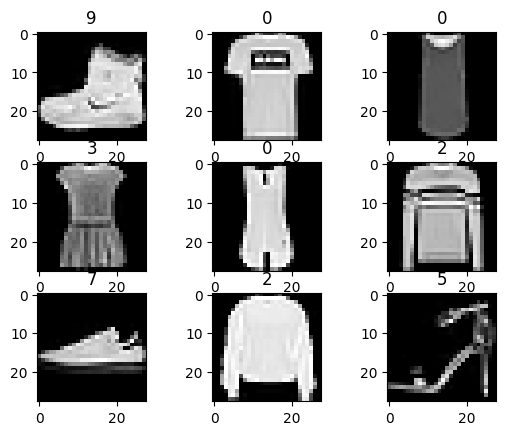

In [14]:
fig, axs = plt.subplots(nrows=3, ncols=3)
for i in range(9):
    ax = axs.flatten()[i]
    img, label = training_data[i]
    img.shape
    
    ax.imshow(img[0, :, :], cmap="grey")
    ax.set_title(label)

    # figure.add_subplot(rows, cols, i)
    # plt.title(labels_map[label])
    # plt.axis("off")
    # plt.imshow(img.squeeze(), cmap="gray")

### ça sert surtout à faire des NN

In [19]:
from torch import nn

In [20]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [21]:
model = NeuralNetwork().to("cuda")
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


#### visualisation du model

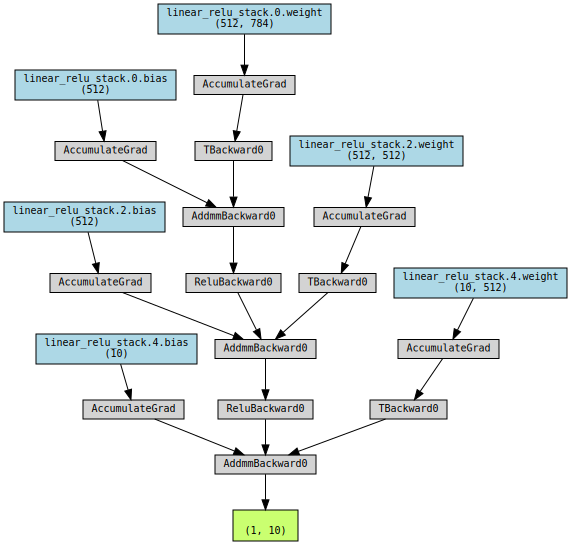

In [22]:
from torchviz import make_dot

model = NeuralNetwork()
x = img
y = model(x)
make_dot(y, params=dict(model.named_parameters()))

#### on lance la descente de gradient et on mesure le score (accuracy)

In [23]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [24]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [25]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.314277  [   64/60000]
loss: 2.301562  [ 6464/60000]
loss: 2.278778  [12864/60000]
loss: 2.270397  [19264/60000]
loss: 2.259754  [25664/60000]
loss: 2.235122  [32064/60000]
loss: 2.247074  [38464/60000]
loss: 2.216440  [44864/60000]
loss: 2.216109  [51264/60000]
loss: 2.177400  [57664/60000]
Test Error: 
 Accuracy: 35.0%, Avg loss: 2.180029 

Epoch 2
-------------------------------
loss: 2.198493  [   64/60000]
loss: 2.185397  [ 6464/60000]
loss: 2.132857  [12864/60000]
loss: 2.139125  [19264/60000]
loss: 2.107298  [25664/60000]
loss: 2.050169  [32064/60000]
loss: 2.078198  [38464/60000]
loss: 2.008635  [44864/60000]
loss: 2.009273  [51264/60000]
loss: 1.929444  [57664/60000]
Test Error: 
 Accuracy: 55.9%, Avg loss: 1.938939 

Epoch 3
-------------------------------
loss: 1.979891  [   64/60000]
loss: 1.946105  [ 6464/60000]
loss: 1.837790  [12864/60000]
loss: 1.860531  [19264/60000]
loss: 1.773168  [25664/60000]
loss: 1.716300  [32064/600